## Arbeiten mit Daten in Pandas 

In [85]:
import pandas as pd
from matplotlib import pyplot as plt

In [86]:
df= pd.read_csv(
    "../data/eistage.csv",      # Pfad zur CSV-Datei
    sep=";",                    # Spalten sind durch ; getrennt
    skiprows=2,                 # Erste Zeile überspringen
    nrows=70,                   # Nur 70 Zeilen einlesen
    usecols=[3, 5, 6],          # Nur die Spalten 3, 5 und 6 verwenden
    parse_dates=["year"],       # Spalte "year" als Datum interpretieren
    na_values=[1900, -999, 999],# Diese Werte als fehlende Werte behandeln
    names=["year", "heat", "ice"], # Neue Spaltennamen festlegen
    index_col=0                 # Erste Spalte als Index verwenden
)

## Data Exploration 

In [87]:
df.info()  # Zeigt Informationen über den DataFrame (Spalten, Datentypen, fehlende Werte)

<class 'pandas.DataFrame'>
DatetimeIndex: 70 entries, 1955-01-01 to 2024-01-01
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   heat    70 non-null     int64
 1   ice     70 non-null     int64
dtypes: int64(2)
memory usage: 1.6 KB


In [88]:
df.head()   # Zeigt die ersten 5 Zeilen des DataFrames an

,heat,ice
year,,
1955-01-01,1,25
1956-01-01,3,46
1957-01-01,10,20
1958-01-01,9,11
1959-01-01,5,17


In [89]:
df_neu = df.tail(10)   # Zeigt die letzten 10 Zeilen des DataFrames an

In [90]:
df.head(10).tail(3).head(1)  # Method Chaining: mehrere Methoden werden verkettet, um schrittweise Daten auszuwählen

,heat,ice
year,,
1962-01-01,14,25


In [91]:
df.describe()

,heat,ice
count,70.000000,70.000000
mean,15.371429,20.414286
std,11.007470,12.062029
min,0.000000,2.000000
25%,6.500000,12.250000
50%,13.000000,19.500000
75%,21.000000,25.000000
max,45.000000,63.000000


## Daten manipulieren (Protection)

In [92]:
df["heat"]  # Gibt die Spalte "heat" aus dem DataFrame zurück, also bestimte Spalte zurückgeben

year
1955-01-01     1
1956-01-01     3
1957-01-01    10
1958-01-01     9
1959-01-01     5
              ..
2020-01-01    21
2021-01-01    24
2022-01-01    31
2023-01-01    32
2024-01-01    45
Name: heat, Length: 70, dtype: int64

In [93]:
df[["heat", "ice"]]  # Äußere [] = Auswahl von Spalten, innere [] = Liste mit mehreren Spaltennamen

,heat,ice
year,,
1955-01-01,1,25
1956-01-01,3,46
1957-01-01,10,20
1958-01-01,9,11
1959-01-01,5,17
...,...,...
2020-01-01,21,3
2021-01-01,24,7
2022-01-01,31,6


Eine einzelne Spalte eines DataFrames ist eine Series, mehrere Spalten zusammen ergeben wieder einen DataFrame.

## Daten Manipulieren (Restriction)

In [94]:
df.loc[df["heat"] > 10]  # Wählt alle Zeilen aus, bei denen der Wert in "heat" größer als 10 ist, unlogisch iwie 

,heat,ice
year,,
1961-01-01,11,29
1962-01-01,14,25
1963-01-01,17,63
1964-01-01,17,42
1967-01-01,17,14
1971-01-01,15,30
1972-01-01,13,27
1974-01-01,11,3
1981-01-01,11,17


In [95]:
df.loc[(df["heat"] > 10) & (df["ice"] < 5)]  # Wählt alle Zeilen aus, bei denen "heat" > 10 und gleichzeitig "ice" < 5 ist

,heat,ice
year,,
1974-01-01,11,3
2015-01-01,42,2
2019-01-01,38,3
2020-01-01,21,3
2023-01-01,32,2
2024-01-01,45,2


In [96]:
from datetime import datetime as dt  # Importiert datetime und kürzt es als dt ab

date_value = dt(year=1974, month=1, day=1)  # Erstellt ein Datumsobjekt für den 01.01.1974

df.iloc[0]  # Gibt die erste Zeile des DataFrames über den Positionsindex aus

heat     1
ice     25
Name: 1955-01-01 00:00:00, dtype: int64

In [97]:
df.loc[df.index == date_value]  # Wählt die Zeile aus, deren Index dem Datum in date_value entspricht

,heat,ice
year,,
1974-01-01,11,3


## Plotting in Python

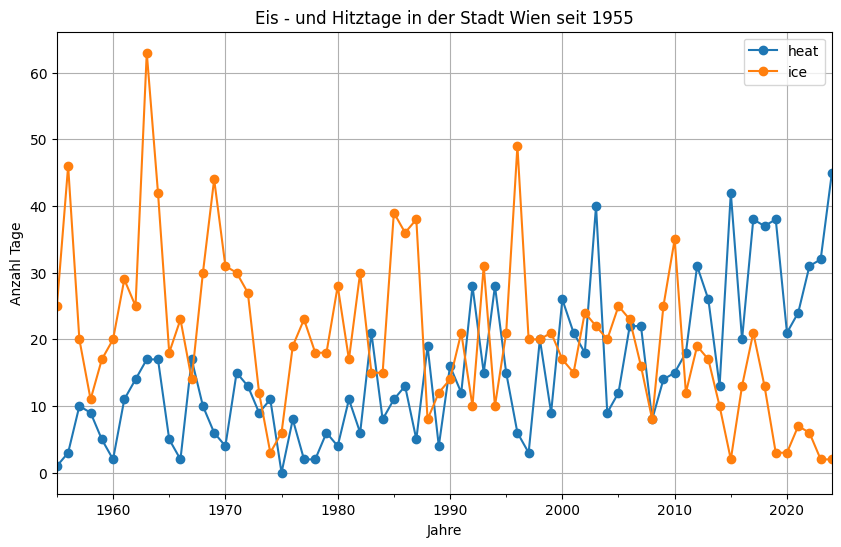

In [107]:
df.plot(
    kind="line",
    marker = "o",
    figsize=(10,6)
    )

plt.xlabel("Jahre")
plt.ylabel("Anzahl Tage")
plt.title("Eis - und Hitztage in der Stadt Wien seit 1955")
plt.grid()
plt.savefig("../output/eistage.png")

<Axes: xlabel='heat', ylabel='ice'>

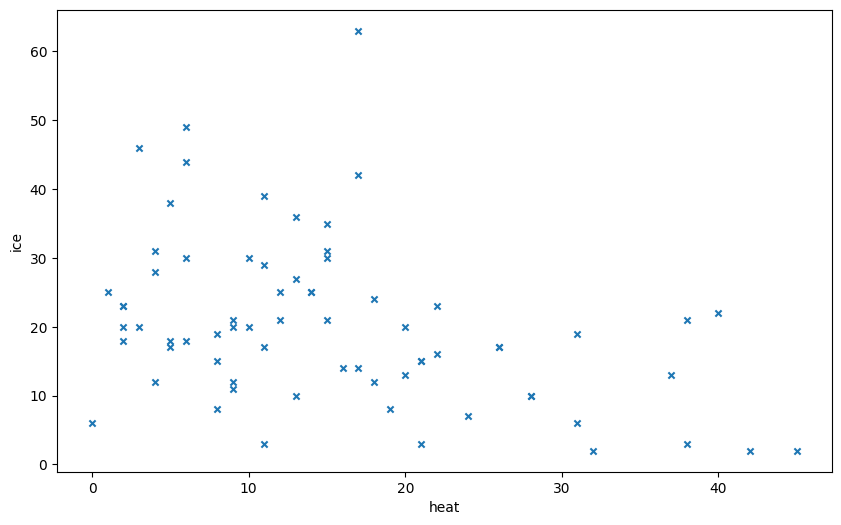

In [122]:
df.plot(kind = "scatter", x="heat", y="ice", figsize=(10,6),marker="x")


In [112]:
df.corr()

,heat,ice
heat,1.000000,-0.391623
ice,-0.391623,1.000000


<Axes: xlabel='year'>

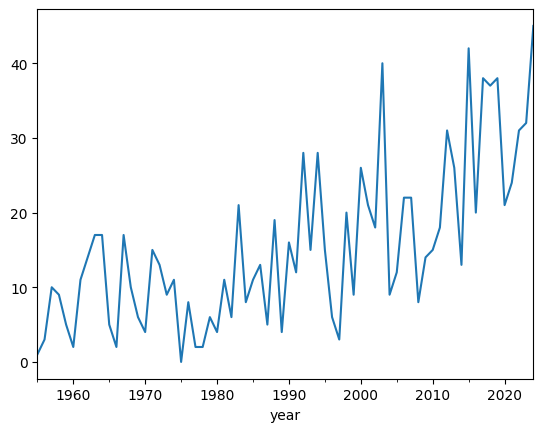

In [129]:
df["heat"].plot()

<Axes: >

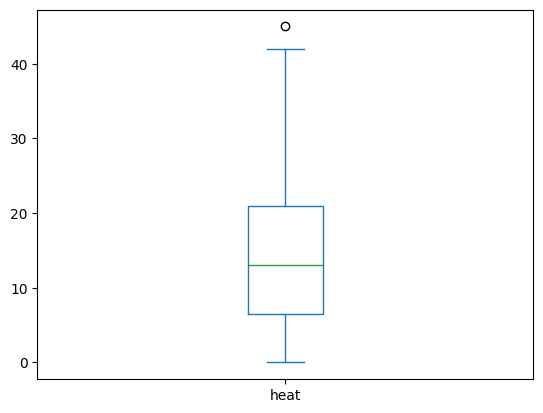

In [127]:
df["heat"].plot(kind="box")

In [136]:
df["heat"].rolling(5)  # Erstellt ein Rolling-Window mit einer Größe von 5 Zeilen für gleitende Berechnungen

Rolling [window=5,center=False,method=single]

In [138]:
df["heat"].rolling(5).mean()  # Berechnet den gleitenden Durchschnitt über jeweils 5 Zeilen

year
1955-01-01     NaN
1956-01-01     NaN
1957-01-01     NaN
1958-01-01     NaN
1959-01-01     5.6
              ... 
2020-01-01    30.8
2021-01-01    31.6
2022-01-01    30.2
2023-01-01    29.2
2024-01-01    30.6
Name: heat, Length: 70, dtype: float64

<Axes: xlabel='year'>

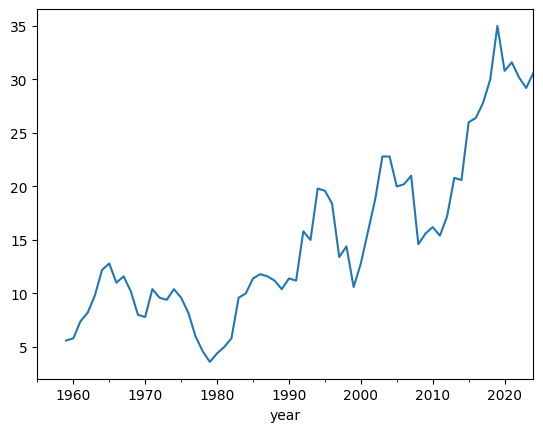

In [141]:
df["heat"].rolling(5).mean().plot()  

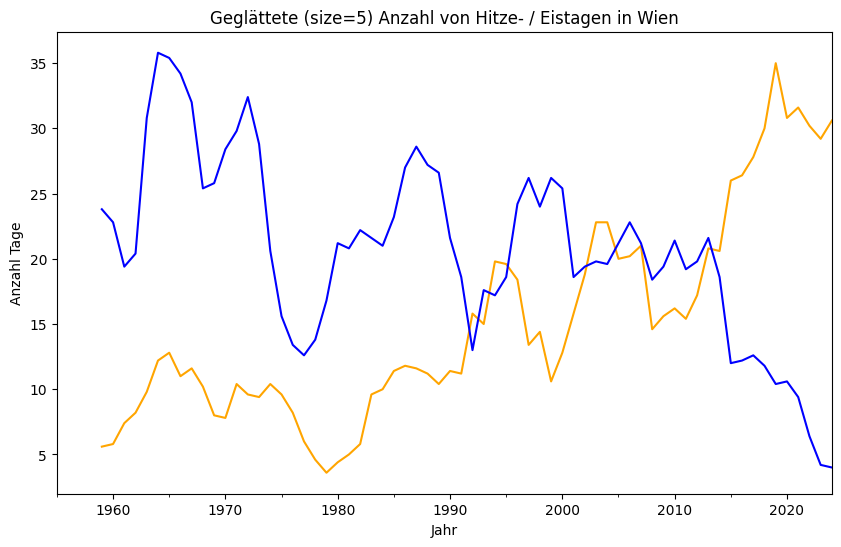

In [146]:
df["heat"].rolling(5).mean().plot(figsize=(10,6), color="orange")  
df["ice"].rolling(5).mean().plot(figsize=(10,6), color="blue")  

plt.title("Geglättete (size=5) Anzahl von Hitze- / Eistagen in Wien")
plt.ylabel("Anzahl Tage")
plt.xlabel("Jahr")

plt.savefig("../output/eistage_smooth.png")